In [1]:
import gymnasium as gym
import matplotlib.pyplot as plt
import numpy as np

from stable_baselines3 import PPO
from stable_baselines3.common.callbacks import EvalCallback
from stable_baselines3.common.env_util import make_vec_env
from stable_baselines3.common.vec_env import VecMonitor

### Add mbt-gym to path

In [2]:
import sys
sys.path.append("../../")

In [3]:
from mbt_gym.agents.BaselineAgents import CarteaJaimungalMmAgent
from mbt_gym.gym.helpers.generate_trajectory import generate_trajectory
from mbt_gym.gym.StableBaselinesTradingEnvironment import StableBaselinesTradingEnvironment
from mbt_gym.gym.TradingEnvironment import TradingEnvironment
from mbt_gym.gym.wrappers import *
from mbt_gym.rewards.RewardFunctions import PnL, CjMmCriterion
from mbt_gym.stochastic_processes.midprice_models import BrownianMotionMidpriceModel
from mbt_gym.stochastic_processes.arrival_models import PoissonArrivalModel
from mbt_gym.stochastic_processes.fill_probability_models import ExponentialFillFunction
from mbt_gym.gym.ModelDynamics import LimitOrderModelDynamics

### Create market making environment

In [4]:
import sys
sys.path.append("../") # This version of the notebook is in the subfolder "notebooks" of the repo

import gym
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.integrate import quad

from copy import deepcopy


from mbt_gym.agents.BaselineAgents import *
from mbt_gym.gym.TradingEnvironment import TradingEnvironment
from mbt_gym.gym.helpers.generate_trajectory import generate_trajectory
from mbt_gym.gym.helpers.plotting import *
from mbt_gym.stochastic_processes.midprice_models import *
from mbt_gym.stochastic_processes.arrival_models import *
from mbt_gym.stochastic_processes.fill_probability_models import *
import torch
#print(torch.cuda.is_available())
#print(torch.cuda.get_device_name())
from mbt_gym.gym.ModelDynamics import LimitOrderModelDynamics


In [5]:
seed = 3
num_trajectories = 10000

## Building the enviroment

In [6]:
def get_as_env(num_trajectories:int = 1, gamma:float=1, psi:float = 15.0):
    midprice_model = ArithmeticBrownianMotionWithFadsMidpriceModelPartialInformation(initial_price=initial_price, drift=mu,
                                                 volatility=sigma, fads_proportion=fads_proportion, eta=eta, step_size=terminal_time/n_steps,
                                                 terminal_time=terminal_time,
                                                 num_trajectories=num_trajectories, seed=seed)
    arrival_model = ModifiedPoissonArrivalModel(phi=phi,
                                                psi=psi,
                                                gamma=gamma,
                                                fads_proportion=fads_proportion,
                                                sigma=sigma,
                                                step_size=terminal_time/n_steps,
                                                num_trajectories=num_trajectories,
                                                seed=seed)
    fill_probability_model = ExponentialFillFunction(fill_exponent=k, 
                                                     step_size=terminal_time/n_steps,
                                                     num_trajectories=num_trajectories,
                                                     seed=seed)
    LOtrader = LimitOrderModelDynamics(midprice_model = midprice_model, arrival_model = arrival_model, 
                                fill_probability_model = fill_probability_model,
                                num_trajectories = num_trajectories, seed=seed)
    reward = CjMmCriterion(per_step_inventory_aversion = big_phi,
                           terminal_inventory_aversion = alpha,
                           terminal_time = terminal_time)
    env_params = dict(terminal_time=terminal_time, 
                      n_steps=n_steps,
                      seed = seed,
                      initial_inventory = initial_inventory,
                      model_dynamics = LOtrader,
                      reward_function = reward,
                      max_inventory=n_steps,
                      normalise_action_space = False,
                      normalise_observation_space = False,
                      num_trajectories=num_trajectories)
    return TradingEnvironment(**env_params)

## Varying Gamma

### Parameters

In [7]:
initial_price = 100
terminal_time = 1.0
sigma = 1.0
n_steps = 100
initial_inventory = 0
fads_proportion= 0.6 # p is defined directly inside the ArithmeticBrownianMotionWithFadsMidpriceModel class as sqrt(1-q^2)
eta = 10.0
phi = 15
k = 1
gamma_values = [0, 1, 2, 3]
alpha=0.001
mu=0
big_phi=0.1
psi=15.0

In [8]:
# # OU parameters
# u0 = 0.0
# xi = 1.0

# def m(t, eta):
#     return u0 * np.exp(-eta * t)

# def v(t, eta):
#     return (xi**2) / (2.0 * eta) * (1.0 - np.exp(-2.0 * eta * t))

# def compute_psi(q, eta, gamma):
#     c = gamma * sigma * q
#     def integrand(t):
#         return np.exp(c * m(t, eta) + 0.5 * (c**2) * v(t, eta))
#     denom, _ = quad(integrand, 0.0, terminal_time)
#     return (30.0 - phi * terminal_time) / denom

# # compute psi for each gamma
# psi_values = {gamma: compute_psi(fads_proportion, eta, gamma) for gamma in gamma_values}

# # pretty print
# for gamma, val in psi_values.items():
#     print(f"gamma={gamma} -> psi={val:.6f}")

### Full Information

In [9]:

results_dict_full_info = {}
for gamma in gamma_values:
    vec_env = get_as_env(num_trajectories=num_trajectories, gamma=gamma, psi=psi)

    vec_as = OptimizedFullInfoMMwithFadsInformedUniformedTradersAgent(env=vec_env)

    #observations, actions, rewards = generate_trajectory(vec_env, vec_as)
    _, _, rewards = generate_trajectory(vec_env, vec_as)
    results, _, total_rewards = generate_results_table_and_hist(
        vec_env=vec_env, agent=vec_as
    )
    del rewards, total_rewards

    results_dict_full_info[gamma] = dict(
        results=results,
        #rewards=total_rewards,
        #obs=observations
    )

✓ Pre-computed ODE solutions for 100 time points
✓ Pre-computed ODE solutions for 100 time points


/Users/andrea/Desktop/gitProject/mbt_gym/Experiments_MMwithFadsInfUninfTraders/PnL_plots_no_rescaling_phi/../../mbt_gym/agents/BaselineAgents.py:794: UserWarning: MM agent is quoting a negative spread
  warnings.warn("MM agent is quoting a negative spread")


✓ Pre-computed ODE solutions for 100 time points


/Users/andrea/Desktop/gitProject/mbt_gym/Experiments_MMwithFadsInfUninfTraders/PnL_plots_no_rescaling_phi/../../mbt_gym/agents/BaselineAgents.py:794: UserWarning: MM agent is quoting a negative spread
  warnings.warn("MM agent is quoting a negative spread")


✓ Pre-computed ODE solutions for 100 time points


/Users/andrea/Desktop/gitProject/mbt_gym/Experiments_MMwithFadsInfUninfTraders/PnL_plots_no_rescaling_phi/../../mbt_gym/agents/BaselineAgents.py:794: UserWarning: MM agent is quoting a negative spread
  warnings.warn("MM agent is quoting a negative spread")


In [10]:
header = f"{'Fads Prop':>10} | {'Psi':>10} | {'Mean PnL':>10} | {'Std PnL':>10} | {'Mean Term Inv':>15} | {'Std Term Inv':>13}"
print(header)
print("-" * len(header))

for gamma, result in results_dict_full_info.items():
    mean_pnl = result['results'].loc['Inventory', 'Mean PnL']
    std_pnl = result['results'].loc['Inventory', 'Std PnL']
    mean_inv = result['results'].loc['Inventory', 'Mean terminal inventory']
    std_inv = result['results'].loc['Inventory', 'Std terminal inventory']
    print(f"{gamma:10.2f} | {psi:10.4f} | {mean_pnl:10.2f} | {std_pnl:10.2f} | {mean_inv:15.2f} | {std_inv:13.2f}")


 Fads Prop |        Psi |   Mean PnL |    Std PnL |   Mean Term Inv |  Std Term Inv
-----------------------------------------------------------------------------------
      0.00 |    15.0000 |      21.46 |       4.79 |            0.02 |          2.21
      1.00 |    15.0000 |      21.42 |       4.75 |            0.02 |          2.16
      2.00 |    15.0000 |      21.53 |       4.76 |            0.03 |          2.15
      3.00 |    15.0000 |      21.81 |       4.79 |            0.03 |          2.18


### Cartea Jaimungal Penalva

In [11]:
results_dict_CJP = {}
for gamma in gamma_values:
    vec_env = get_as_env(
        num_trajectories=num_trajectories,
        gamma=gamma,
        psi=psi
    )

    vec_as = ModifiedCarteaJaimungalMmAgent(env=vec_env)

    #observations, actions, rewards = generate_trajectory(vec_env, vec_as)
    _, _, rewards = generate_trajectory(vec_env, vec_as)
    results, _, total_rewards = generate_results_table_and_hist(
        vec_env=vec_env, agent=vec_as
    )
    del rewards, total_rewards

    results_dict_CJP[gamma] = dict(
        results=results,
        #rewards=total_rewards,
        #obs=observations
    )

In [12]:
header = f"{'Fads Prop':>10} | {'Psi':>10} | {'Mean PnL':>10} | {'Std PnL':>10} | {'Mean Term Inv':>15} | {'Std Term Inv':>13}"
print(header)
print("-" * len(header))

for gamma, result in results_dict_CJP.items():
    mean_pnl = result['results'].loc['Inventory', 'Mean PnL']
    std_pnl = result['results'].loc['Inventory', 'Std PnL']
    mean_inv = result['results'].loc['Inventory', 'Mean terminal inventory']
    std_inv = result['results'].loc['Inventory', 'Std terminal inventory']
    print(f"{gamma:10.2f} | {psi:10.4f} | {mean_pnl:10.2f} | {std_pnl:10.2f} | {mean_inv:15.2f} | {std_inv:13.2f}")


 Fads Prop |        Psi |   Mean PnL |    Std PnL |   Mean Term Inv |  Std Term Inv
-----------------------------------------------------------------------------------
      0.00 |    15.0000 |      21.40 |       4.83 |            0.03 |          2.94
      1.00 |    15.0000 |      21.33 |       4.81 |            0.05 |          2.96
      2.00 |    15.0000 |      21.41 |       4.82 |            0.04 |          3.06
      3.00 |    15.0000 |      21.66 |       4.85 |            0.05 |          3.23


### Partial Information

In [13]:
results_dict_partial_information = {}
for gamma in gamma_values:
    vec_env = get_as_env(
        num_trajectories=num_trajectories,
        gamma=gamma,
        psi=psi
    )

    vec_as = OptimizedPartialInfoMMwithFadsInformedUniformedTradersAgent(env=vec_env)

    #observations, actions, rewards = generate_trajectory(vec_env, vec_as)
    _, _, rewards = generate_trajectory(vec_env, vec_as)
    results, _, total_rewards = generate_results_table_and_hist(
        vec_env=vec_env, agent=vec_as
    )
    del rewards, total_rewards

    results_dict_partial_information[gamma] = dict(
        results=results,
        #rewards=total_rewards,
        #obs=observations
    )

✓ Pre-computed ODE solutions for 100 time points
✓ Pre-computed ODE solutions for 100 time points
✓ Pre-computed ODE solutions for 100 time points
✓ Pre-computed ODE solutions for 100 time points


In [14]:
header = f"{'Fads Prop':>10} | {'Psi':>10} | {'Mean PnL':>10} | {'Std PnL':>10} | {'Mean Term Inv':>15} | {'Std Term Inv':>13}"
print(header)
print("-" * len(header))

for gamma, result in results_dict_partial_information.items():
    mean_pnl = result['results'].loc['Inventory', 'Mean PnL']
    std_pnl = result['results'].loc['Inventory', 'Std PnL']
    mean_inv = result['results'].loc['Inventory', 'Mean terminal inventory']
    std_inv = result['results'].loc['Inventory', 'Std terminal inventory']
    print(f"{gamma:10.2f} | {psi:10.4f} | {mean_pnl:10.2f} | {std_pnl:10.2f} | {mean_inv:15.2f} | {std_inv:13.2f}")


 Fads Prop |        Psi |   Mean PnL |    Std PnL |   Mean Term Inv |  Std Term Inv
-----------------------------------------------------------------------------------
      0.00 |    15.0000 |      21.36 |       4.79 |            0.01 |          2.17
      1.00 |    15.0000 |      21.30 |       4.77 |            0.02 |          2.18
      2.00 |    15.0000 |      21.39 |       4.78 |            0.02 |          2.24
      3.00 |    15.0000 |      21.64 |       4.80 |            0.03 |          2.35


### Final Plot

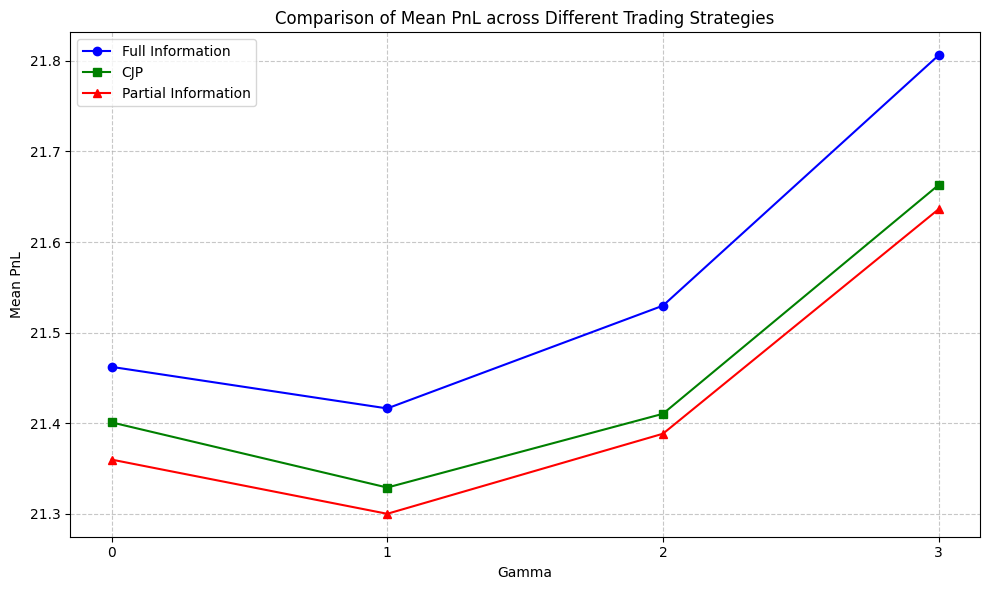

In [15]:
# Extract mean PnL values for each approach
mean_pnl_full = [results_dict_full_info[gamma]['results'].loc['Inventory', 'Mean PnL'] for gamma in gamma_values]
mean_pnl_cjp = [results_dict_CJP[gamma]['results'].loc['Inventory', 'Mean PnL'] for gamma in gamma_values]
mean_pnl_partial = [results_dict_partial_information[gamma]['results'].loc['Inventory', 'Mean PnL'] for gamma in gamma_values]

# Create the plot
plt.figure(figsize=(10, 6))
plt.plot(gamma_values, mean_pnl_full, 'o-', label='Full Information', color='blue')
plt.plot(gamma_values, mean_pnl_cjp, 's-', label='CJP', color='green')
plt.plot(gamma_values, mean_pnl_partial, '^-', label='Partial Information', color='red')

plt.xlabel('Gamma')
plt.ylabel('Mean PnL')
plt.title('Comparison of Mean PnL across Different Trading Strategies')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

# Add x-axis ticks at each fads proportion value
plt.xticks(gamma_values)

plt.tight_layout()
plt.show()